In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt 
import seaborn as sns  
from sklearn.preprocessing import LabelEncoder
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/hr-data/PerformanceRating.csv
/kaggle/input/hr-data/RatingLevel.csv
/kaggle/input/hr-data/Employee.csv
/kaggle/input/hr-data/SatisfiedLevel.csv
/kaggle/input/hr-data/EducationLevel.csv


In [24]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [4]:
filepath='/kaggle/input/hr-data/Employee.csv'
emp_data=pd.read_csv(filepath)
emp_data.head()

,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,MaritalStatus,Salary,StockOptionLevel,OverTime,HireDate,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,Divorced,102059,1,No,2012-01-03,No,10,4,9,7
1,CBCB-9C9D,Leonerd,Aland,Male,38,Some Travel,Sales,23,CA,White,...,Single,157718,0,Yes,2012-01-04,No,10,6,10,0
2,95D7-1CE9,Ahmed,Sykes,Male,43,Some Travel,Human Resources,29,CA,Asian or Asian American,...,Married,309964,1,No,2012-01-04,No,10,6,10,8
3,47A0-559B,Ermentrude,Berrie,Non-Binary,39,Some Travel,Technology,12,IL,White,...,Married,293132,0,No,2012-01-05,No,10,10,10,0
4,42CC-040A,Stace,Savege,Female,29,Some Travel,Human Resources,29,CA,White,...,Single,49606,0,No,2012-01-05,Yes,6,1,1,6


In [5]:
filepath="/kaggle/input/hr-data/PerformanceRating.csv"
perf_rating=pd.read_csv(filepath)
perf_rating

,PerformanceID,EmployeeID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,PR01,79F7-78EC,1/2/2013,5,4,5,1,0,4,4,4
1,PR02,B61E-0F26,1/3/2013,5,4,4,1,3,4,4,3
2,PR03,F5E3-48BB,1/3/2013,3,4,5,3,2,3,5,4
3,PR04,0678-748A,1/4/2013,5,3,2,2,0,2,3,2
4,PR05,541F-3E19,1/4/2013,5,2,3,1,0,4,4,3
...,...,...,...,...,...,...,...,...,...,...,...
6704,PR995,4F28-CFAF,3/14/2016,5,3,3,3,1,5,5,4
6705,PR996,7C80-94E0,3/14/2016,3,5,4,2,1,3,4,4
6706,PR997,8233-2483,3/14/2016,3,4,2,3,1,2,3,2
6707,PR998,8A5B-3D6E,3/15/2016,5,2,5,2,2,4,3,3


In [6]:
#merge data
merged_data = pd.merge(emp_data,perf_rating, on='EmployeeID')
merged_data.head()


,EmployeeID,FirstName,LastName,Gender,Age,BusinessTravel,Department,DistanceFromHome (KM),State,Ethnicity,...,PerformanceID,ReviewDate,EnvironmentSatisfaction,JobSatisfaction,RelationshipSatisfaction,TrainingOpportunitiesWithinYear,TrainingOpportunitiesTaken,WorkLifeBalance,SelfRating,ManagerRating
0,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1295,10/30/2016,3,3,2,3,0,4,3,3
1,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR1908,10/30/2017,4,4,5,3,1,2,3,2
2,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR2617,10/30/2018,5,5,4,3,0,4,5,5
3,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR3436,10/30/2019,1,3,2,3,1,3,5,4
4,3012-1A41,Leonelle,Simco,Female,30,Some Travel,Sales,27,IL,White,...,PR411,10/31/2014,3,4,2,1,0,3,4,3


In [7]:
def nulls_summary_table(df):
    """
    Returns a summary table showing null value counts and percentage
    
    Parameters:
    df (DataFrame): Dataframe to check
    
    Returns:
    null_values (DataFrame)
    """
    null_values = pd.DataFrame(merged_data.isnull().sum())
    null_values[1] = null_values[0]/len(merged_data)
    null_values.columns = ['null_count','null_pct']
    return null_values

nulls_summary_table(merged_data)

,null_count,null_pct
EmployeeID,0,0.0
FirstName,0,0.0
LastName,0,0.0
Gender,0,0.0
Age,0,0.0
BusinessTravel,0,0.0
Department,0,0.0
DistanceFromHome (KM),0,0.0
State,0,0.0
Ethnicity,0,0.0


In [8]:
merged_data.columns

Index(['EmployeeID', 'FirstName', 'LastName', 'Gender', 'Age',
       'BusinessTravel', 'Department', 'DistanceFromHome (KM)', 'State',
       'Ethnicity', 'Education', 'EducationField', 'JobRole', 'MaritalStatus',
       'Salary', 'StockOptionLevel', 'OverTime', 'HireDate', 'Attrition',
       'YearsAtCompany', 'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceID', 'ReviewDate',
       'EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating'],
      dtype='object')

In [9]:
merged_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6709 entries, 0 to 6708
Data columns (total 33 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   EmployeeID                       6709 non-null   object
 1   FirstName                        6709 non-null   object
 2   LastName                         6709 non-null   object
 3   Gender                           6709 non-null   object
 4   Age                              6709 non-null   int64 
 5   BusinessTravel                   6709 non-null   object
 6   Department                       6709 non-null   object
 7   DistanceFromHome (KM)            6709 non-null   int64 
 8   State                            6709 non-null   object
 9   Ethnicity                        6709 non-null   object
 10  Education                        6709 non-null   int64 
 11  EducationField                   6709 non-null   object
 12  JobRole                          6

In [10]:
# Apply log transformation to Salary to reduce skewness
merged_data["Salary"] = np.log1p(merged_data["Salary"])

In [11]:
# Drop original categorical columns and EmployeeID
merged_data=merged_data.drop(columns=["EmployeeID", "FirstName", "LastName", "PerformanceID", "ReviewDate",'HireDate'])

In [12]:
#  Identify categorical columns
categorical_cols = merged_data.select_dtypes(include=['object']).columns.tolist()

# Exclude the target variable if it exists
if "Attrition" in categorical_cols:
    categorical_cols.remove("Attrition")

#  Handle missing values in categorical columns
merged_data[categorical_cols] = merged_data[categorical_cols].fillna("Missing")

#  Initialize and apply OneHotEncoder
ohe = OneHotEncoder(drop='first', sparse=False)
categorical_encoded = pd.DataFrame(ohe.fit_transform(merged_data[categorical_cols]))

# Set column names for the encoded data
categorical_encoded.columns = ohe.get_feature_names_out(categorical_cols)

#  Preserve the original index
categorical_encoded.index = merged_data.index



/usr/local/lib/python3.10/dist-packages/sklearn/preprocessing/_encoders.py:868: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


In [13]:
# Convert target variable to binary
merged_data["Attrition"] = merged_data["Attrition"].map({"No": 0, "Yes": 1})

In [14]:
#  Concatenate with numerical columns (optional)
numerical_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns.tolist()
df_final = pd.concat([merged_data[numerical_cols], categorical_encoded], axis=1)

# Display the final encoded dataset
df_final.head()

,Age,DistanceFromHome (KM),Education,Salary,StockOptionLevel,Attrition,YearsAtCompany,YearsInMostRecentRole,YearsSinceLastPromotion,YearsWithCurrManager,...,JobRole_Machine Learning Engineer,JobRole_Manager,JobRole_Recruiter,JobRole_Sales Executive,JobRole_Sales Representative,JobRole_Senior Software Engineer,JobRole_Software Engineer,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,30,27,5,11.533316,1,0,10,4,9,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,30,27,5,11.533316,1,0,10,4,9,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,30,27,5,11.533316,1,0,10,4,9,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,30,27,5,11.533316,1,0,10,4,9,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,30,27,5,11.533316,1,0,10,4,9,7,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
df_final.columns

Index(['Age', 'DistanceFromHome (KM)', 'Education', 'Salary',
       'StockOptionLevel', 'Attrition', 'YearsAtCompany',
       'YearsInMostRecentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction',
       'RelationshipSatisfaction', 'TrainingOpportunitiesWithinYear',
       'TrainingOpportunitiesTaken', 'WorkLifeBalance', 'SelfRating',
       'ManagerRating', 'Gender_Male', 'Gender_Non-Binary',
       'Gender_Prefer Not To Say', 'BusinessTravel_No Travel ',
       'BusinessTravel_Some Travel', 'Department_Sales',
       'Department_Technology', 'State_IL', 'State_NY',
       'Ethnicity_Asian or Asian American',
       'Ethnicity_Black or African American',
       'Ethnicity_Mixed or multiple ethnic groups',
       'Ethnicity_Native Hawaiian ', 'Ethnicity_Other ', 'Ethnicity_White',
       'EducationField_Computer Science', 'EducationField_Economics',
       'EducationField_Human Resources', 'EducationField_Information Systems',


In [16]:
# Split data into training and testing sets
X = df_final.drop(columns=["Attrition"])
y = df_final["Attrition"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
# Scale numerical feature
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) 

In [18]:
# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [19]:
# Train Logistic Regression
lr_model = LogisticRegression(solver='liblinear')
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)
# Evaluate Logistic Regression
print("--- Logistic Regression ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


--- Logistic Regression ---
Accuracy: 0.9016
Confusion Matrix:
 [[836  54]
 [ 78 374]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93       890
           1       0.87      0.83      0.85       452

    accuracy                           0.90      1342
   macro avg       0.89      0.88      0.89      1342
weighted avg       0.90      0.90      0.90      1342



Logistic Regression Coefficient Importance:
 YearsAtCompany                               1.865200
JobRole_Data Scientist                       1.249795
YearsSinceLastPromotion                      1.186773
OverTime_Yes                                 0.952079
JobRole_Software Engineer                    0.834419
Age                                          0.648385
Gender_Prefer Not To Say                     0.520474
EducationField_Information Systems           0.519681
JobRole_Sales Representative                 0.507505
EducationField_Marketing                     0.503129
JobRole_Engineering Manager                  0.487731
Department_Sales                             0.487555
Department_Technology                        0.476469
BusinessTravel_No Travel                     0.458365
EducationField_Other                         0.442160
EducationField_Marketing                     0.394017
JobRole_HR Business Partner                  0.380576
YearsWithCurrManager                 

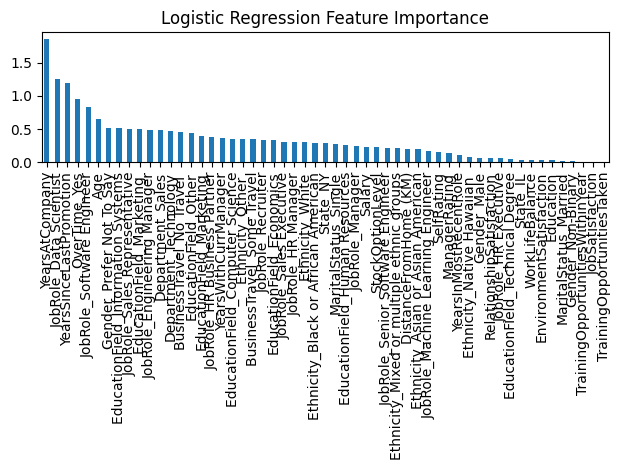

In [20]:
# Feature Importance for Logistic Regression (based on coefficients)
lr_importance = pd.Series(np.abs(lr_model.coef_[0]), index=X.columns)
print("Logistic Regression Coefficient Importance:\n", lr_importance.sort_values(ascending=False))
lr_importance.sort_values(ascending=False).plot(kind='bar', title='Logistic Regression Feature Importance')
plt.tight_layout()
plt.show()

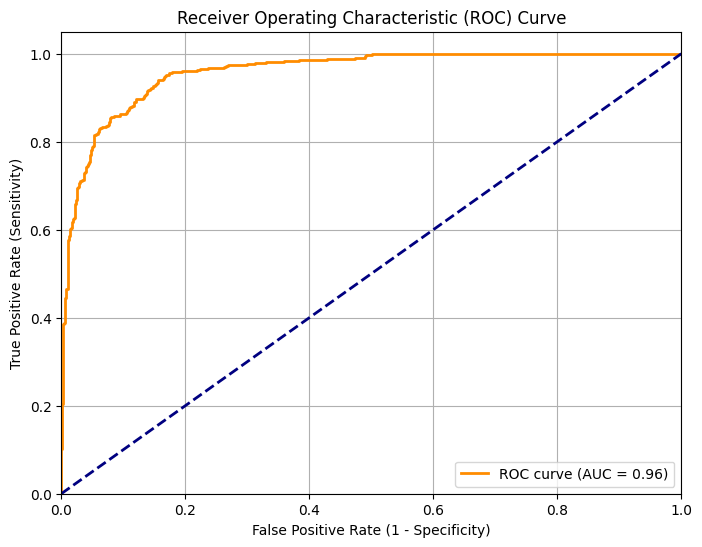

In [25]:
# Initialize and train the logistic regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predict probabilities for the positive class
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Compute ROC curve metrics
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Random classifier line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
# Step 6: Save predictions
output = pd.DataFrame({'Predicted': y_pred})
output.to_csv('test_data_predictions.csv', index=False)
import pandas as pd
from IPython.display import FileLink

filename = 'test_data_predictions.csv'
output.to_csv(filename, index=False)
print(f"File saved as {filename}")

FileLink(filename)